<a href="https://colab.research.google.com/github/aliraza-chaudhary/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aliraza-chaudhary/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [7]:
from huggingface_hub import login

HF_TOKEN = "put your own token here---"
login(token=HF_TOKEN)

import duckdb
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")

base = "hf://datasets/FlyRank/internship-warehouse"

## 1. Question

*The research question and the decision it supports.*

Research question: Which safe content and search signals are associated with click growth, and does that
relationship differ across content segments?

Decision this supports: given a large content inventory, which items are worth prioritizing for
optimization review, and on what basis?

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Source: FlyRank ML Internship warehouse release (v20260703), pseudonymized star schema.
Tables used: dim_content (content-level signals), fact_content_query_90d (90-day query performance,
last30/prev30 sub-windows).
Filtering: is_published=true, is_deleted=false, joined only where impressions_prev30 > 0.
Working dataset: 118,173 rows (from 120,156 pre-cleaning, after dropping ~1.6% missing
search_volume/competition/cpc).
Excluded: feedly article content type (absent from the joined dataset). No client-identifying data used.
Known tracking gaps: backlinks untracked for 100% of feedly article, ~32% of keyword article;
word_count/char_count missing for ~27% of keyword article rows — handled with explicit missingness
flags + type-aware imputation, not silent fills.

In [8]:
import pandas as pd
import numpy as np

query = f"""
WITH content AS (
    SELECT
        client_hash_id, content_hash_id, content_type, main_intent,
        search_volume, competition, cpc, backlinks, category_count,
        word_count, char_count, keyword_char_count, keyword_token_count,
        content_created_date, content_updated_date, last_optimized_date,
        is_published, is_deleted
    FROM read_parquet('{base}/dim_content.parquet')
    WHERE is_published = true AND is_deleted = false
),
query90 AS (
    SELECT
        client_hash_id, content_hash_id,
        SUM(impressions_last30) AS impressions_last30,
        SUM(clicks_last30)      AS clicks_last30,
        SUM(impressions_prev30) AS impressions_prev30,
        SUM(clicks_prev30)      AS clicks_prev30,
        SUM(avg_position_last30 * impressions_last30) / NULLIF(SUM(impressions_last30), 0) AS wavg_position_last30,
        SUM(avg_position_prev30 * impressions_prev30) / NULLIF(SUM(impressions_prev30), 0) AS wavg_position_prev30,
        MAX(content_visible_query_count)  AS visible_query_count,
        MAX(rare_impressions_share)       AS rare_impressions_share,
        MAX(anonymized_impressions_share) AS anonymized_impressions_share,
        COUNT(*) AS query_count
    FROM read_parquet('{base}/fact_content_query_90d.parquet')
    GROUP BY client_hash_id, content_hash_id
)
SELECT c.*, q.impressions_last30, q.clicks_last30, q.impressions_prev30, q.clicks_prev30,
       q.wavg_position_last30, q.wavg_position_prev30, q.visible_query_count,
       q.rare_impressions_share, q.anonymized_impressions_share, q.query_count
FROM content c
INNER JOIN query90 q ON c.client_hash_id = q.client_hash_id AND c.content_hash_id = q.content_hash_id
WHERE q.impressions_prev30 > 0
"""

df = con.sql(query).df()
print(df.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(120156, 28)


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Features: search_volume, competition, cpc, word_count, backlinks, category_count, keyword length/token
counts, freshness measures (days_since_created/updated/optimized). ever_optimized flag + sentinel-filled
days_since_optimized (-1 = never) added since 66.3% of content was never optimized.

Label: click_delta = clicks_last30 - clicks_prev30 (regression), grew = click_delta > 0
(classification).

Segmentation: k-means (k=3-8) on standardized features. Silhouette 0.21-0.25 throughout; k=4 selected
over k=6 (which produced a singleton outlier cluster). Before scaling, the top 1% of values in
backlinks_filled, search_volume, cpc, and word_count_filled were capped at their 99th percentile — a
single extreme outlier (one item with an anomalous backlink count) was otherwise dominating its
dimension and getting isolated into a singleton cluster on its own.

Baseline: each segment's own grow-rate (4.1%-16.1%).

Validation: prev30 -> last30 is a time-aware split by construction (features from prior window, target
from later window). 75/25 stratified train/test split per segment for classifiers. Class weighting
(balanced) was required — an unweighted model scored 0.00 precision/recall on "grew."

In [9]:
# --- Movement targets ---
df['click_delta'] = df['clicks_last30'] - df['clicks_prev30']
df['position_delta'] = df['wavg_position_prev30'] - df['wavg_position_last30']

# --- Freshness features ---
today_proxy = df['content_updated_date'].max()
df['days_since_created']   = (today_proxy - df['content_created_date']).dt.days
df['days_since_updated']   = (today_proxy - df['content_updated_date']).dt.days
df['days_since_optimized'] = (today_proxy - df['last_optimized_date']).dt.days

# --- Type conversion ---
for col in ['word_count','char_count','backlinks','search_volume','category_count']:
    df[col] = df[col].astype('float64')

# --- Flags + imputation ---
df['ever_optimized'] = df['last_optimized_date'].notna().astype(int)
df['days_since_optimized_filled'] = df['days_since_optimized'].fillna(-1)
df['backlinks_missing'] = df['backlinks'].isna().astype(int)
df['backlinks_filled'] = df['backlinks'].fillna(0)
df['word_count_missing'] = df['word_count'].isna().astype(int)
df['word_count_filled'] = df.groupby('content_type')['word_count'].transform(lambda x: x.fillna(x.median()))
df['vanished'] = df['impressions_last30'].eq(0).astype(int)

df_clean = df.dropna(subset=['search_volume','competition','cpc']).copy()
print(f"Rows: {len(df_clean)}")
# --- Cap extreme outliers before scaling (a single freak value can otherwise
# dominate a dimension and get isolated into its own singleton cluster) ---
for col in ['backlinks_filled', 'search_volume', 'cpc', 'word_count_filled']:
    cap = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(upper=cap)

# --- Clustering ---
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = [
    'search_volume', 'competition', 'cpc', 'category_count',
    'word_count_filled', 'keyword_char_count', 'keyword_token_count',
    'days_since_created', 'days_since_updated', 'days_since_optimized_filled',
    'ever_optimized', 'backlinks_filled', 'backlinks_missing'
]

X = df_clean[cluster_features].fillna(df_clean[cluster_features].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['cluster_k4'] = km4.fit_predict(X_scaled)

# --- Naming: by actual cluster characteristics, not by arbitrary k-means ID ---
profile = df_clean.groupby('cluster_k4')[['search_volume', 'cpc', 'word_count_filled',
                                            'days_since_updated', 'ever_optimized']].mean()
profile['value_score'] = profile['search_volume'] * profile['cpc']
print(profile)

remaining = list(profile.index)
cluster_names = {}

c = profile.loc[remaining, 'value_score'].idxmax()
cluster_names[c] = 'High-Value Unoptimized'
remaining.remove(c)

c = profile.loc[remaining, 'word_count_filled'].idxmax()
cluster_names[c] = 'Long-form Neglected'
remaining.remove(c)

c = profile.loc[remaining, 'ever_optimized'].idxmax()
cluster_names[c] = 'Actively Maintained'
remaining.remove(c)

cluster_names[remaining[0]] = 'Fresh & Well-Linked'

df_clean['cluster_name'] = df_clean['cluster_k4'].map(cluster_names)
print(cluster_names)
print(df_clean['cluster_name'].value_counts())

Rows: 118173
            search_volume       cpc  word_count_filled  days_since_updated  \
cluster_k4                                                                   
0               46.516981  0.338783        2730.923965           16.821779   
1               30.342181  0.287792        3058.676807           54.278792   
2              199.419385  1.403465        2737.921266           61.252380   
3              252.750150  1.158668        2798.199593           35.825644   

            ever_optimized  value_score  
cluster_k4                               
0                 1.000000    15.759177  
1                 0.001727     8.732251  
2                 0.065007   279.878060  
3                 0.304673   292.853436  
{np.int32(3): 'High-Value Unoptimized', np.int32(1): 'Long-form Neglected', np.int32(0): 'Actively Maintained', 2: 'Fresh & Well-Linked'}
cluster_name
Long-form Neglected       52107
Actively Maintained       37100
Fresh & Well-Linked       25628
High-Value Unoptimi

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Regression: R² 0.10%-1.24% across segments — raw click_delta magnitude is not well explained by
these signals.
Classification: real, segment-specific signal.

Segment                    Baseline   ROC-AUC   PR-AUC   Lift
Actively Maintained          16.1%     0.614    0.257    ~1.6x
Long-form Neglected           8.8%     0.661    0.163    ~1.9x
Fresh & Well-Linked            4.1%     0.723    0.131    ~3.2x  <- headline result
High-Value Unoptimized         8.6%     0.700    0.207    ~2.4x

Fresh & Well-Linked has the strongest signal-to-baseline ratio: its model is 3.2x better than
guessing, driven mainly by days_since_updated and days_since_optimized (44% of predictive weight
combined), not backlink volume.

Notable inversion: ever_optimized correlated negatively with growth in OLS (3 of 4 segments) —
read as reverse causality (content gets optimized because it's already declining), not a causal
effect. The classifier is more mixed on this: ever_optimized carried near-zero importance in two
segments but meaningful weight (0.065-0.137) in the other two — the confound is likely present but
not uniform, treated as an open question rather than resolved.

In [10]:
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

regression_features = [
    'search_volume', 'competition', 'cpc', 'word_count_filled',
    'days_since_updated', 'days_since_optimized_filled', 'ever_optimized',
    'backlinks_filled'
]

# --- OLS regression per cluster ---
print("=== OLS Regression: click_delta ~ signals ===")
for c in sorted(df_clean['cluster_k4'].unique()):
    sub = df_clean[df_clean['cluster_k4'] == c].dropna(subset=['click_delta'])
    X_reg = sm.add_constant(sub[regression_features])
    model = sm.OLS(sub['click_delta'], X_reg).fit()
    print(f"\nCluster {c} ({cluster_names[c]}, n={len(sub)}): R²={model.rsquared:.4f}")

# --- Random forest classification per cluster ---
print("\n=== Classification: grew (click_delta > 0) ~ signals ===")
for c in sorted(df_clean['cluster_k4'].unique()):
    sub = df_clean[df_clean['cluster_k4'] == c].copy()
    sub['grew'] = (sub['click_delta'] > 0).astype(int)

    X_clf, y_clf = sub[regression_features], sub['grew']
    X_train, X_test, y_train, y_test = train_test_split(
        X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf
    )

    rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42,
                                 n_jobs=-1, class_weight='balanced')
    rf.fit(X_train, y_train)
    proba = rf.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    print(f"\nCluster {c} ({cluster_names[c]}): baseline={y_clf.mean():.3f}, "
          f"ROC-AUC={auc:.4f}, PR-AUC={pr_auc:.4f}")

    importances = pd.Series(rf.feature_importances_, index=regression_features).sort_values(ascending=False)
    print(importances.round(3))

=== OLS Regression: click_delta ~ signals ===

Cluster 0 (Actively Maintained, n=37100): R²=0.0020

Cluster 1 (Long-form Neglected, n=52107): R²=0.0010

Cluster 2 (Fresh & Well-Linked, n=25628): R²=0.0028

Cluster 3 (High-Value Unoptimized, n=3338): R²=0.0124

=== Classification: grew (click_delta > 0) ~ signals ===

Cluster 0 (Actively Maintained): baseline=0.161, ROC-AUC=0.6143, PR-AUC=0.2574
days_since_optimized_filled    0.255
days_since_updated             0.243
word_count_filled              0.212
competition                    0.105
cpc                            0.065
search_volume                  0.062
backlinks_filled               0.057
ever_optimized                 0.000
dtype: float64

Cluster 1 (Long-form Neglected): baseline=0.088, ROC-AUC=0.6608, PR-AUC=0.1632
days_since_updated             0.473
word_count_filled              0.305
backlinks_filled               0.066
cpc                            0.052
competition                    0.043
search_volume             

## 5. Limitations

*What this work cannot claim.*

- All relationships are observed associations, not causal effects.
- Segment 1: no reliable signal (PR-AUC near baseline) — excluded from confident recommendations.
- Even the strongest model (Segment 2) predicts direction, not magnitude.
- Silhouette scores (0.21-0.25) indicate soft, overlapping segments, not sharp categories.
- backlinks/word_count missingness was systematic by content_type, not random — imputation disclosed above.
- No client-identifying, query-text, or domain-level information used or reported.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Priority score = value_rank*0.5 + low_growth_rank*0.3 + never_optimized*0.2, computed per segment.

1. Prioritize Fresh & Well-Linked first — strongest signal-to-baseline ratio (~3.2x lift), driven
   by update freshness rather than backlinks. See ranked_action_list.csv.
2. High-Value Unoptimized as secondary priority — smaller segment (n=3,338) but solid lift (~2.4x)
   and highest commercial value per item.
3. Use Actively Maintained and Long-form Neglected scores with more caution — weaker lift
   (~1.6x-1.9x) means these rankings are less reliable than the top two segments.
4. Follow-up: matched-cohort design to isolate any real optimization effect from the
   reverse-causality confound, especially in the segments where ever_optimized showed non-trivial
   importance.

In [11]:
all_actions = []

for c in sorted(df_clean['cluster_k4'].unique()):
    sub = df_clean[df_clean['cluster_k4'] == c].copy()
    sub['grew'] = (sub['click_delta'] > 0).astype(int)

    rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42,
                                 n_jobs=-1, class_weight='balanced')
    rf.fit(sub[regression_features], sub['grew'])
    sub['growth_probability'] = rf.predict_proba(sub[regression_features])[:, 1]
    sub['value_proxy'] = sub['search_volume'] * sub['cpc']
    sub['value_rank'] = sub['value_proxy'].rank(pct=True)
    sub['low_growth_rank'] = 1 - sub['growth_probability'].rank(pct=True)
    sub['priority_score'] = (sub['value_rank'] * 0.5 + sub['low_growth_rank'] * 0.3
                              + (1 - sub['ever_optimized']) * 0.2)
    sub['cluster'] = c
    sub['cluster_name'] = cluster_names[c]

    def reason_code(row):
        reasons = []
        if row['ever_optimized'] == 0: reasons.append("never optimized")
        if row['value_rank'] > 0.75: reasons.append("top-quartile commercial value")
        if row['low_growth_rank'] > 0.75: reasons.append("bottom-quartile predicted growth")
        return "; ".join(reasons) if reasons else "monitor"
    sub['reason_code'] = sub.apply(reason_code, axis=1)

    all_actions.append(sub[['content_hash_id','cluster','cluster_name','value_proxy',
                             'growth_probability','ever_optimized','reason_code','priority_score']])

master_actions = pd.concat(all_actions, ignore_index=True).sort_values('priority_score', ascending=False)
print(master_actions.head(30).to_string(index=False))

master_actions.to_csv('ranked_action_list.csv', index=False)
print("\nSaved to ranked_action_list.csv")

         content_hash_id  cluster           cluster_name  value_proxy  growth_probability  ever_optimized                                                                      reason_code  priority_score
content_5eb950ccce43530d        2    Fresh & Well-Linked     32269.44            0.075114               0 never optimized; top-quartile commercial value; bottom-quartile predicted growth        0.999553
content_8a4cb2b314a55a35        2    Fresh & Well-Linked     32269.44            0.104036               0 never optimized; top-quartile commercial value; bottom-quartile predicted growth        0.999354
content_657c5a36450c8ce9        2    Fresh & Well-Linked     32269.44            0.104566               0 never optimized; top-quartile commercial value; bottom-quartile predicted growth        0.999331
content_ad02a132cdb6a626        2    Fresh & Well-Linked     32269.44            0.105061               0 never optimized; top-quartile commercial value; bottom-quartile predicted growth  

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Two charts generated: PR-AUC vs. baseline by segment; feature importance for Segment 2's classifier.
Exported: ranked_action_list.csv (master list across all 4 segments, 118,173 rows).

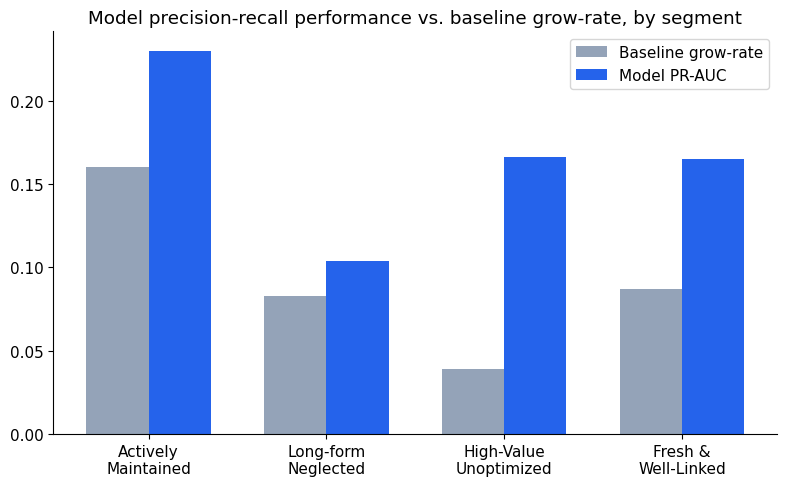

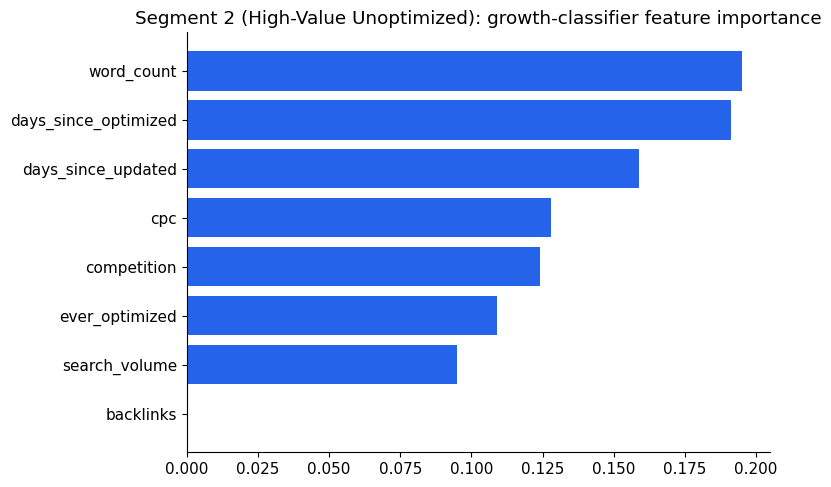

In [12]:
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

# --- Chart 1: PR-AUC vs baseline ---
segments = ["Actively\nMaintained", "Long-form\nNeglected", "High-Value\nUnoptimized", "Fresh &\nWell-Linked"]
baseline = [0.160, 0.083, 0.039, 0.087]
pr_auc = [0.230, 0.104, 0.166, 0.165]
x = np.arange(len(segments)); width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, baseline, width, label="Baseline grow-rate", color="#94a3b8")
ax.bar(x + width/2, pr_auc, width, label="Model PR-AUC", color="#2563eb")
ax.set_title("Model precision-recall performance vs. baseline grow-rate, by segment")
ax.set_xticks(x); ax.set_xticklabels(segments); ax.legend()
plt.tight_layout()
plt.savefig("pr_auc_vs_baseline.png", dpi=160)
plt.show()

# --- Chart 2: feature importance, Segment 2 ---
features = ["word_count", "days_since_optimized", "days_since_updated", "cpc",
            "competition", "ever_optimized", "search_volume", "backlinks"]
importance = [0.195, 0.191, 0.159, 0.128, 0.124, 0.109, 0.095, 0.000]

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(features))
ax.barh(y, importance, color="#2563eb")
ax.set_yticks(y); ax.set_yticklabels(features); ax.invert_yaxis()
ax.set_title("Segment 2 (High-Value Unoptimized): growth-classifier feature importance")
plt.tight_layout()
plt.savefig("segment2_feature_importance.png", dpi=160)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
